# MindStream — FER+ Emotion Model

**Dataset**: [arnabkumarroy02/ferplus](https://www.kaggle.com/datasets/arnabkumarroy02/ferplus)  
- 8 emotions: `angry`, `contempt`, `disgust`, `fear`, `happy`, `neutral`, `sad`, `surprise`
- Already balanced + augmented by the uploader
- Splits: Train (~66k) / Validation (~8k) / Test (~3.5k)
- Native size: 112 × 112 → we resize to 128 × 128 for richer MobileNetV2 features

Two-phase training: head warmup (backbone frozen) → fine-tune (top layers unfrozen).

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, Input
from keras.models import Model
from keras import optimizers, callbacks, losses
from keras.applications import MobileNetV2
from keras.applications.mobilenet_v2 import preprocess_input
from keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.10.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
DATA_DIR = r"E:\Core-AI\DATASETS\FER2013plus"        
CHECKPOINT_DIR = r"E:\Core-AI\MODELS\CV"

# Order is fixed so that class indices stay stable across runs and match the report later.
FER_CLASSES = [
    "angry",      # 0  – negative (priority)
    "contempt",   # 1  – negative (priority)
    "disgust",    # 2  – negative (priority)
    "fear",       # 3  – negative (priority)
    "happy",      # 4  – mild
    "neutral",    # 5  – mild
    "sad",        # 6  – negative (priority)
    "surprise",   # 7  – mild
]
NUM_CLASSES = len(FER_CLASSES)

# Negative / high-stakes emotions we want the model to care about more
NEGATIVE_EMOTIONS = {"angry", "contempt", "disgust", "fear", "sad"}

IMG_SIZE = (128, 128)   # native FER+ is 112×112; 128 gives MobileNetV2 a bit more spatial room
BATCH_SIZE = 32

EPOCHS_WARMUP = 12
EPOCHS_FINETUNE = 25
LABEL_SMOOTHING = 0.1

# Relative emphasis multipliers (applied on top of balanced class weights)
NEGATIVE_WEIGHT_MULT = 1.45   # stronger focus on negative emotions
OTHER_WEIGHT_MULT = 0.85      # mild down-weight of happy / neutral / surprise

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

train_dir = os.path.join(DATA_DIR, "Train")
val_dir   = os.path.join(DATA_DIR, "Validation")
test_dir  = os.path.join(DATA_DIR, "Test")

print("Classes:", FER_CLASSES)
print("Negative priority:", sorted(NEGATIVE_EMOTIONS))

Classes: ['angry', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Negative priority: ['angry', 'contempt', 'disgust', 'fear', 'sad']


## 1. Data generators + augmentation

- MobileNetV2’s own `preprocess_input` (scales to `[-1, 1]`) instead of a plain `rescale=1/255`.
- Face-friendly geometric + photometric augmentations (rotation, shift, shear, zoom, brightness, horizontal flip).
- `zoom_range` acts as a lightweight random-crop substitute.
- `color_mode='rgb'` — even if source images are grayscale, Keras will replicate the channel so ImageNet weights remain valid.

In [3]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=18,
    width_shift_range=0.12,
    height_shift_range=0.12,
    shear_range=0.12,
    zoom_range=0.18,
    brightness_range=[0.75, 1.25],
    horizontal_flip=True,
    fill_mode="nearest",
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    color_mode="rgb",
    classes=FER_CLASSES,
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    color_mode="rgb",
    classes=FER_CLASSES,
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    color_mode="rgb",
    classes=FER_CLASSES,
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("Class indices:", train_generator.class_indices)
print(f"Train samples: {train_generator.samples} | Val: {val_generator.samples} | Test: {test_generator.samples}")

Found 66379 images belonging to 8 classes.
Found 7341 images belonging to 8 classes.
Found 3123 images belonging to 8 classes.
Class indices: {'angry': 0, 'contempt': 1, 'disgust': 2, 'fear': 3, 'happy': 4, 'neutral': 5, 'sad': 6, 'surprise': 7}
Train samples: 66379 | Val: 7341 | Test: 3123


## 2. Class weights — balanced baseline + negative-emotion boost

Even though the Kaggle FER+ upload is already balanced, we still compute the classic inverse-frequency weights and then **multiply** the five negative classes by `NEGATIVE_WEIGHT_MULT`. This gently pushes the optimizer to care more about angry / contempt / disgust / fear / sad without breaking the overall training dynamics.

In [4]:
print(train_generator.class_indices)
print(len(train_generator.class_indices))

{'angry': 0, 'contempt': 1, 'disgust': 2, 'fear': 3, 'happy': 4, 'neutral': 5, 'sad': 6, 'surprise': 7}
8


In [5]:
print("Unique class IDs:", np.unique(train_generator.classes))
print("Number of unique classes:", len(np.unique(train_generator.classes)))

Unique class IDs: [0 1 2 3 4 5 6 7]
Number of unique classes: 8


In [6]:
print(train_generator.class_indices)

{'angry': 0, 'contempt': 1, 'disgust': 2, 'fear': 3, 'happy': 4, 'neutral': 5, 'sad': 6, 'surprise': 7}


In [7]:
# Adjust this list to match your dataset's label order
FER_CLASSES = [
    "angry",
    "contempt",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise",  # remove if you only have 7 classes
]

# Emotions you want to treat as "negative" and up-weight
NEGATIVE_EMOTIONS = {
    "angry",
    "contempt",
    "disgust",
    "fear",
    "sad",
}

# Multipliers: scale the balanced weights
NEGATIVE_WEIGHT_MULT = 1.0   # weight for negative emotions
OTHER_WEIGHT_MULT = 0.6      # weight for other emotions

# Compute base balanced weights (inverse frequency)
base_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes,
)

# Build final class weight dict with custom scaling
class_weight_dict = {}
for i, w in enumerate(base_weights):
    name = FER_CLASSES[i]
    if name in NEGATIVE_EMOTIONS:
        class_weight_dict[i] = float(w * NEGATIVE_WEIGHT_MULT)
    else:
        class_weight_dict[i] = float(w * OTHER_WEIGHT_MULT)

print("Final class weights (higher = more emphasis):")
for i, name in enumerate(FER_CLASSES):
    tag = "NEG" if name in NEGATIVE_EMOTIONS else "mild"
    print(f"  {name:10s} ({tag:4s}): {class_weight_dict[i]:.3f}")

Final class weights (higher = more emphasis):
  angry      (NEG ): 1.037
  contempt   (NEG ): 1.037
  disgust    (NEG ): 1.037
  fear       (NEG ): 1.037
  happy      (mild): 0.622
  neutral    (mild): 0.480
  sad        (NEG ): 1.037
  surprise   (mild): 0.622


## 3. Model architecture

MobileNetV2 (ImageNet) + compact classifier head — same shape you already know:

`GlobalAveragePooling → BatchNorm → Dropout → Dense(128) → Dropout → Dense(8, softmax)`

Backbone starts frozen; we unfreeze later from a fixed layer index.

In [8]:
def build_model(input_shape, num_classes):
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet",
    )
    base_model.trainable = False

    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.40)(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.30)(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs, name="MindStream_FERPlus_MobileNetV2")
    return model, base_model

model, base_model = build_model(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES,
)
model.summary()

Model: "MindStream_FERPlus_MobileNetV2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 mobilenetv2_1.00_128 (Funct  (None, 4, 4, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization (BatchN  (None, 1280)             5120      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                    

## 4. Callbacks

**Callbacks** are special functions that are automatically executed at specific points during the training of a deep learning model.

They are used to **monitor and control the training process** without manually interrupting it.

### Main Uses of Callbacks

- 🛑 **Stop training early** when the model stops improving.
- 💾 **Save the best model** during training.
- 📉 **Reduce the learning rate** when improvement slows down.
- 📊 **Monitor training performance** such as accuracy and loss.
- 📝 **Record training information** for later analysis.

### Common Callbacks

| Callback | Purpose |
|---|---|
| `EarlyStopping` | Stops training when performance stops improving |
| `ModelCheckpoint` | Saves the best model |
| `ReduceLROnPlateau` | Reduces learning rate when progress slows |
| `TensorBoard` | Visualizes and monitors training |

> **In simple words:** Callbacks are **automatic helpers that monitor and manage the training of a deep learning model.**

In [9]:
checkpoint_path = os.path.join(CHECKPOINT_DIR, "best_ferplus_emotion.keras")

cb_list = [
    callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1,
    ),
]

## Phase 1 — Warm up the classification head (backbone frozen)

`label_smoothing=0.1` softens the hard one-hot targets so the model does not become over-confident — especially useful when some emotions (contempt, disgust) are visually subtle.

In [10]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss=losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=["accuracy"],
)

history_phase1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_WARMUP,
    class_weight=class_weight_dict,
    callbacks=cb_list,
)

Epoch 1/12
2075/2075 [==============================] - ETA: 0s - loss: 1.4940 - accuracy: 0.4003
Epoch 1: val_accuracy improved from -inf to 0.45280, saving model to E:\Core-AI\MODELS\CV\best_ferplus_emotion.keras
2075/2075 [==============================] - 529s 253ms/step - loss: 1.4940 - accuracy: 0.4003 - val_loss: 1.5786 - val_accuracy: 0.4528 - lr: 0.0010
Epoch 2/12
2075/2075 [==============================] - ETA: 0s - loss: 1.3354 - accuracy: 0.4643
Epoch 2: val_accuracy improved from 0.45280 to 0.47119, saving model to E:\Core-AI\MODELS\CV\best_ferplus_emotion.keras
2075/2075 [==============================] - 160s 77ms/step - loss: 1.3354 - accuracy: 0.4643 - val_loss: 1.5482 - val_accuracy: 0.4712 - lr: 0.0010
Epoch 3/12
2075/2075 [==============================] - ETA: 0s - loss: 1.3012 - accuracy: 0.4811
Epoch 3: val_accuracy improved from 0.47119 to 0.50102, saving model to E:\Core-AI\MODELS\CV\best_ferplus_emotion.keras
2075/2075 [==============================] - 450s 

## Phase 2 — Fine-tune MobileNetV2

Unfreeze the backbone, then re-freeze everything up to layer 100 so only the later blocks + head train at a low learning rate. 

In [11]:
base_model.trainable = True

fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Trainable layers after unfreeze: {sum([l.trainable for l in base_model.layers])} / {len(base_model.layers)}")

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss=losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=["accuracy"],
)

history_phase2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_WARMUP + EPOCHS_FINETUNE,
    initial_epoch=history_phase1.epoch[-1] + 1,
    class_weight=class_weight_dict,
    callbacks=cb_list,
)

print(f"\nTraining complete. Best checkpoint saved to:\n  {checkpoint_path}")

Trainable layers after unfreeze: 54 / 154
Epoch 13/37
2075/2075 [==============================] - ETA: 0s - loss: 1.1550 - accuracy: 0.5723
Epoch 13: val_accuracy improved from 0.52214 to 0.54107, saving model to E:\Core-AI\MODELS\CV\best_ferplus_emotion.keras
2075/2075 [==============================] - 175s 83ms/step - loss: 1.1550 - accuracy: 0.5723 - val_loss: 1.4402 - val_accuracy: 0.5411 - lr: 1.0000e-05
Epoch 14/37
2075/2075 [==============================] - ETA: 0s - loss: 1.0842 - accuracy: 0.6166
Epoch 14: val_accuracy improved from 0.54107 to 0.54162, saving model to E:\Core-AI\MODELS\CV\best_ferplus_emotion.keras
2075/2075 [==============================] - 156s 75ms/step - loss: 1.0842 - accuracy: 0.6166 - val_loss: 1.4388 - val_accuracy: 0.5416 - lr: 1.0000e-05
Epoch 15/37
2075/2075 [==============================] - ETA: 0s - loss: 1.0395 - accuracy: 0.6446
Epoch 15: val_accuracy improved from 0.54162 to 0.59760, saving model to E:\Core-AI\MODELS\CV\best_ferplus_emotio

## 5. Accuracy / loss curves

Stitches phase-1 and phase-2 histories so you can see the jump (or lack of one) when fine-tuning starts.

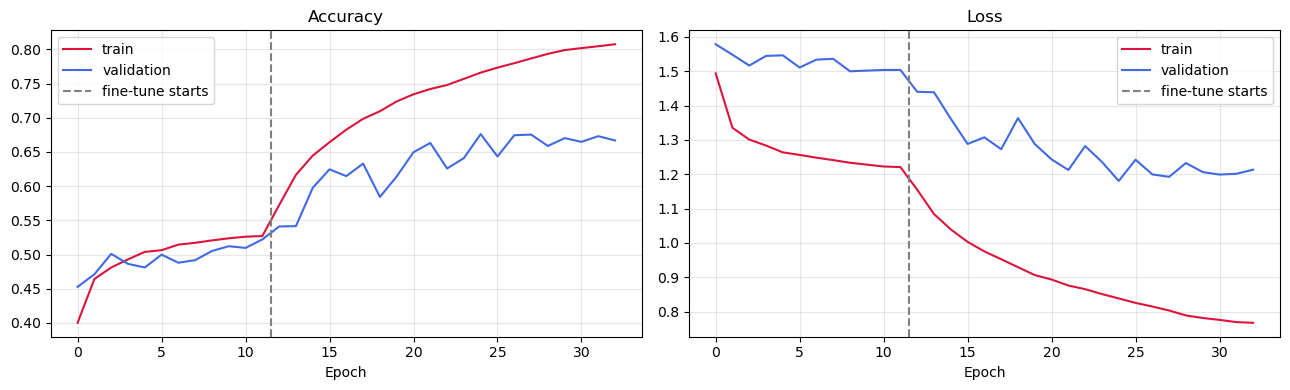

In [12]:
acc = history_phase1.history["accuracy"] + history_phase2.history["accuracy"]
val_acc = history_phase1.history["val_accuracy"] + history_phase2.history["val_accuracy"]
loss = history_phase1.history["loss"] + history_phase2.history["loss"]
val_loss = history_phase1.history["val_loss"] + history_phase2.history["val_loss"]
switch_epoch = len(history_phase1.history["accuracy"])

plt.figure(figsize=(13, 4))

plt.subplot(1, 2, 1)
plt.plot(acc, color="crimson", label="train")
plt.plot(val_acc, color="royalblue", label="validation")
plt.axvline(switch_epoch - 0.5, color="gray", linestyle="--", label="fine-tune starts")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(loss, color="crimson", label="train")
plt.plot(val_loss, color="royalblue", label="validation")
plt.axvline(switch_epoch - 0.5, color="gray", linestyle="--", label="fine-tune starts")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Evaluation on Validation + Test sets

Loads the **best** checkpoint (highest `val_accuracy`) and reports:
- Full classification report (precision / recall / F1)
- Confusion matrix
- Explicit recall numbers for the five negative emotions (the ones we boosted)


========== Validation set ==========
              precision    recall  f1-score   support

       angry      0.700     0.685     0.693      1000
    contempt      0.635     0.582     0.607      1000
     disgust      0.736     0.603     0.663      1000
        fear      0.754     0.749     0.752      1000
       happy      0.794     0.843     0.818      1000
     neutral      0.826     0.582     0.683      1341
         sad      0.476     0.720     0.573      1000
    surprise      0.000     0.000     0.000         0

    accuracy                          0.676      7341
   macro avg      0.615     0.596     0.599      7341
weighted avg      0.709     0.676     0.684      7341

Negative-emotion recall (priority classes):
  angry     : 0.685
  contempt  : 0.582
  disgust   : 0.603
  fear      : 0.749
  sad       : 0.720


c:\Users\LENOVO\miniconda3\envs\tf-gpu\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\LENOVO\miniconda3\envs\tf-gpu\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\LENOVO\miniconda3\envs\tf-gpu\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\LENOVO\miniconda3\envs\tf-gp

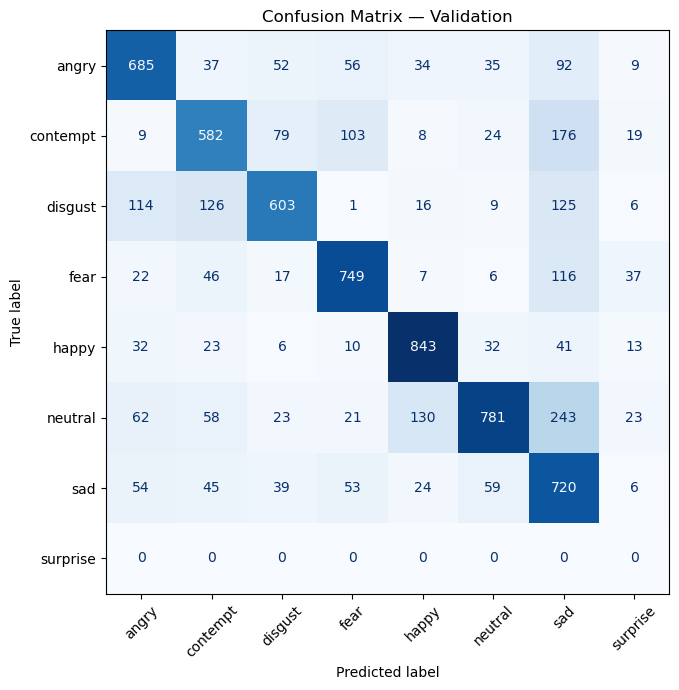


========== Test set ==========
              precision    recall  f1-score   support

       angry      0.679     0.717     0.698       322
    contempt      0.137     0.467     0.212        30
     disgust      0.241     0.667     0.354        21
        fear      0.536     0.612     0.571        98
       happy      0.842     0.879     0.860       929
     neutral      0.852     0.595     0.701      1274
         sad      0.470     0.641     0.542       449
    surprise      0.000     0.000     0.000         0

    accuracy                          0.699      3123
   macro avg      0.470     0.572     0.492      3123
weighted avg      0.755     0.699     0.714      3123

Negative-emotion recall (priority classes):
  angry     : 0.717
  contempt  : 0.467
  disgust   : 0.667
  fear      : 0.612
  sad       : 0.641


c:\Users\LENOVO\miniconda3\envs\tf-gpu\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\LENOVO\miniconda3\envs\tf-gpu\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\LENOVO\miniconda3\envs\tf-gpu\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\LENOVO\miniconda3\envs\tf-gp

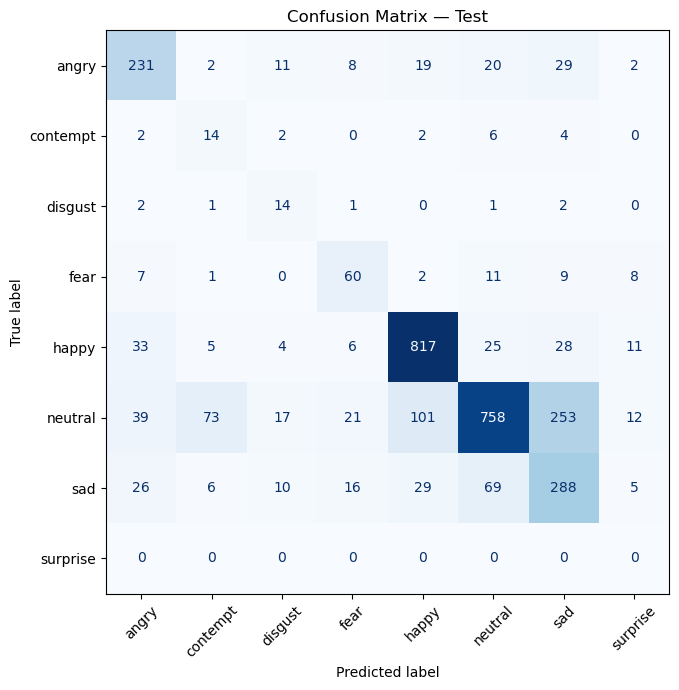

In [13]:
best_model = tf.keras.models.load_model(checkpoint_path)

def evaluate_generator(gen, name):
    gen.reset()
    steps = int(np.ceil(gen.samples / BATCH_SIZE))
    preds = best_model.predict(gen, steps=steps, verbose=0)
    y_pred = np.argmax(preds, axis=1)[: gen.samples]
    y_true = gen.classes

    print(f"\n========== {name} set ==========")
    print(classification_report(y_true, y_pred, target_names=FER_CLASSES, digits=3))

    # Highlight negative-emotion recall
    report = classification_report(y_true, y_pred, target_names=FER_CLASSES, output_dict=True)
    print("Negative-emotion recall (priority classes):")
    for emo in sorted(NEGATIVE_EMOTIONS):
        r = report[emo]["recall"]
        print(f"  {emo:10s}: {r:.3f}")

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 7))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=FER_CLASSES)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
    ax.set_title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()

    return y_true, y_pred, report

_ = evaluate_generator(val_generator, "Validation")
_ = evaluate_generator(test_generator, "Test")

## 7. Quick sanity-check: predict a few random validation images

Visual confirmation that the model is looking at the right facial regions and producing sensible top-1 predictions.

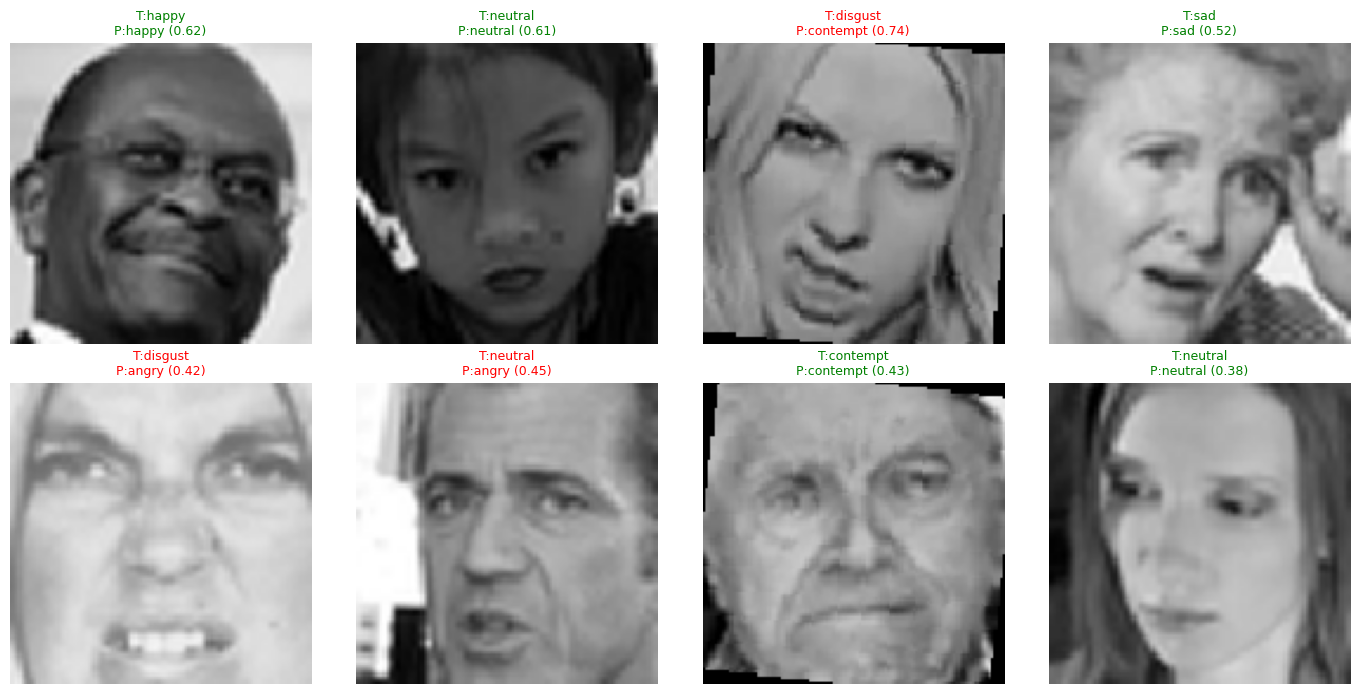

In [15]:
import random
from tensorflow.keras.utils import load_img, img_to_array

def show_random_predictions(gen, n=8):
    # Collect a few file paths + true labels
    paths = gen.filepaths
    labels = gen.classes
    idxs = random.sample(range(len(paths)), k=min(n, len(paths)))

    plt.figure(figsize=(14, 7))
    for i, idx in enumerate(idxs):
        img = load_img(paths[idx], target_size=IMG_SIZE, color_mode="rgb")
        arr = img_to_array(img)
        arr_prep = preprocess_input(arr.copy())
        pred = best_model.predict(np.expand_dims(arr_prep, 0), verbose=0)[0]
        pred_cls = FER_CLASSES[np.argmax(pred)]
        true_cls = FER_CLASSES[labels[idx]]
        conf = pred.max()

        ax = plt.subplot(2, 4, i + 1)
        ax.imshow(img)
        color = "green" if pred_cls == true_cls else "red"
        ax.set_title(f"T:{true_cls}\nP:{pred_cls} ({conf:.2f})", color=color, fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_random_predictions(val_generator, n=8)